In [1]:
import mitsuba as mi
import drjit as dr
import matplotlib.pyplot as plt

mi.set_variant('cuda_ad_rgb')

In [2]:
class thin_lens_sensor (mi.Sensor):
    def __init__(self, props):
        mi.Sensor.__init__(self, props)
        t = props['to_world']
        #print(type(t))
        self.to_world = mi.Transform4d(t)
        #print(type(self.to_world))
        self.foc_len  = mi.Float(props['foc_len'])
        self.img_dist = mi.Float(props['img_dist'])
        self.sen_size = props['sen_size']
        self.lens_rad = mi.Float(props['lens_rad'])
        self.filmsize = (self.sen_size, self.sen_size)
            
    def sample_ray_differential(self, time, sample1, sample2, sample3, active=True):
        
        #print(type(sample3))
        p_a_2d = self.lens_rad * mi.warp.square_to_uniform_disk_concentric(sample3)
        #print(type(p_a_2d))
        p_a = mi.Point3f(p_a_2d[0], p_a_2d[1], mi.Float(0.0))
        
        p_s = mi.Point3f((sample2[0]-0.5) * self.filmsize[0], (sample2[1]-0.5) * self.filmsize[1], -1.0 * self.img_dist)
        
        p_o = p_s / (-1.0 * self.img_dist) * 1/(1/self.foc_len - 1/self.img_dist)
        
        rayd = mi.RayDifferential3f()
        rayd.has_differentials = False
        
        d = dr.normalize(mi.Vector3f(p_o - p_a))
        #print(f"d: {type(d)}")
        #print(f"p_a: {type(p_a)}")
        rayd.d = self.to_world @ d
        rayd.o = self.to_world.transform_affine(p_a)#p_a
        
        
        #rayd.d = dr.normalize(rayd.d)
        #rayd.d = self.to_world.transform_affine(rayd.d)
        
        return (rayd, mi.Color3f(1.0, 1.0, 1.0))

    def traverse(self, callback):
        callback.put_parameter('focal_length', self.foc_len, mi.ParamFlags.Differentiable)

   
    
    def to_string(self):
        return ('thin_lens_sensor[\n'
                '    foc_len=%s,\n'
                '    img_dist=%s,\n'
                '    sen_size=%s,\n'
                '    lens_rad=%s,\n'
                ']' % (self.foc_len, self.img_dist, self.sen_size, self.lens_rad))
        

In [3]:
mi.register_sensor("thin_lens_sensor", lambda props: thin_lens_sensor(props))

In [4]:
g = 8.0
V = 2.0
f = g/(1/V+1)
b = 1/(1/f - 1/g)


In [5]:
scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'prb_projective'
    },

    'sphere' : {
        'type': 'sphere',
        'emitter': {
            'type': 'area',
            'radiance': {
            'type': 'rgb',
            'value': 1.0,
        },
    },
    'center': [0, 0, g+4],
    'radius': 1,
        
    },
    'sensor': {
        'type': 'thin_lens_sensor',
        'to_world': mi.ScalarTransform4f.look_at(origin=[0, 0, 0],
                                                 target=[0, 0, 1],
                                                 up=[0, 1, 0]),
        'foc_len' : f,
        'img_dist': b,
        'sen_size': 10.0,
        'lens_rad': 1.0,
        'film': {'type': 'hdrfilm',
      'width': 100,
      'height': 100,
      'rfilter': {'type': 'gaussian'},
      'pixel_format': 'rgb',
      'component_format': 'float32'},
     'sampler': {'type': 'independent', 'sample_count': 512},
    }
})



In [6]:
ref_image = mi.render(scene)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


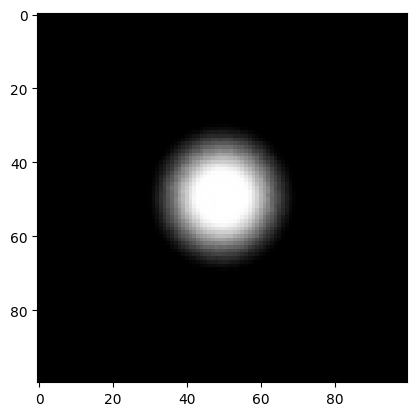

In [7]:
plt.figure()
plt.imshow(ref_image)

In [8]:
params = mi.traverse(scene)

In [9]:
params

SceneParameters[
  ----------------------------------------------------------------------------------------
  Name                                 Flags    Type        Parent
  ----------------------------------------------------------------------------------------
  sensor.focal_length                  ∂        Float       Sensor
  sphere.bsdf.reflectance.value        ∂        Float       UniformSpectrum
  sphere.emitter.sampling_weight                float       AreaLight
  sphere.emitter.radiance.value        ∂        Color3f     SRGBReflectanceSpectrum
  sphere.silhouette_sampling_weight             float       Sphere
  sphere.to_world                      ∂, D     Transform4f Sphere
]

In [10]:
key = 'sensor.focal_length'
params[key]

[5.333333492279053]

In [20]:
params[key] = 4.0
params.update()

[(thin_lens_sensor[
      foc_len=[4.0],
      img_dist=[16.0],
      sen_size=10.0,
      lens_rad=[1.0],
  ],
  {'focal_length'}),
 (Scene[
    children = [
      DirectProjectiveIntegrator[max_depth = 2, rr_depth = 2],
      thin_lens_sensor[
          foc_len=[4.0],
          img_dist=[16.0],
          sen_size=10.0,
          lens_rad=[1.0],
      ],
      Sphere[
        to_world = [[1, 0, 0, 0],
                    [0, 1, 0, 0],
                    [0, 0, 1, 12],
                    [0, 0, 0, 1]],
        center = [0, 0, 12],
        radius = 1,
        surface_area = [12.5664],
        bsdf = SmoothDiffuse[
          reflectance = UniformSpectrum[value=[0]]
        ],
        emitter = AreaLight[
          radiance = SRGBReflectanceSpectrum[
            value = [[1, 1, 1]]
          ],
          surface_area = [12.5664],
          <no medium attached!>
        ]
      ]
    ]
  ],
  {'sensor'})]

In [21]:
img = mi.render(scene)

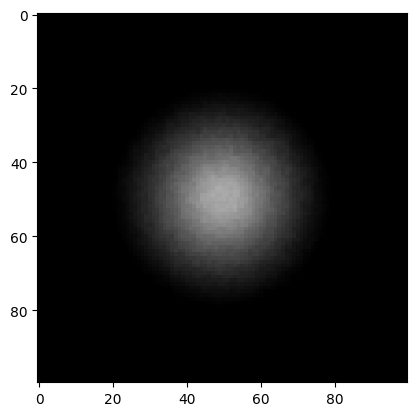

In [22]:
plt.figure()
plt.imshow(img)

In [23]:
opt = mi.ad.Adam(lr=5)
opt[key] = params[key]
params.update(opt);

In [24]:
dr.grad_enabled(params[key])

True

In [25]:
def mse(image):
    return dr.mean(dr.sqr(image - ref_image))

In [26]:
iteration_count = 50

In [28]:
errors = []
for it in range(iteration_count):
    # Perform a (noisy) differentiable rendering of the scene
    image = mi.render(scene, params, spp=32)

    # Evaluate the objective function from the current rendered image
    loss = mse(image)
    print(f"loss: {loss} \n f: {params[key]}")

    # Backpropagate through the rendering process
    dr.backward(loss)

    # Optimizer: take a gradient descent step
    opt.step()

    # Post-process the optimized parameters to ensure legal color values.
    #opt[key] = dr.clamp(opt[key], 0.0, 1.0)

    # Update the scene state to the new optimized values
    params.update(opt)

    # Track the difference between the current color and the true value
    #err_ref = dr.sum(dr.sqr(param_ref - params[key]))
    #print(f"Iteration {it:02d}: parameter error = {err_ref[0]:6f}", end='\r')
    #errors.append(err_ref)
print('\nOptimization complete.')

loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216403424739838] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216403424739838] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]
loss: [0.008216402493417263] 
 f: [4.0]


In [19]:
params[key]

[5.0]

##### Archive

In [121]:
tf = mi.ScalarTransform4d.look_at(origin=[0, 0, 0], target=[0, 0, 1], up=[0, 1, 0])
tf2 = mi.Transform4d(tf)

In [119]:
type(tf)

mitsuba.cuda_ad_rgb.ChainScalarTransform4f

In [122]:
d = mi.Vector3f(1.0,2.0,3.0)

In [129]:
type(tf2 @ d)

mitsuba.cuda_ad_rgb.Point3d